# **Lab project 2: Advanced deep generative models**

**Pablo Martínez Olmos, Vanessa Gómez Verdejo,  Alejandro Lancho Serrano, Emilio Parrado Hernández**

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='https://upload.wikimedia.org/wikipedia/commons/8/88/Acronimo_nombre3l.jpg' width=300 />


# Part 1: Conditional Generation in Deep Generative Models

In this first part, you will progressively explore the design and training of Variational Autoencoders (VAEs) using the **Fashion MNIST** dataset ([torchvision.datasets.FashionMNIST](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html)). The first part will guide you through building a standard VAE, experimenting with different likelihoods, and analyzing the latent space. As you advance, you will extend your models to more expressive approaches, culminating in the implementation and analysis of conditional VAEs. Each section will build upon the previous, helping you understand how architectural choices and conditioning impact generative modeling and representation learning.

The notebook is structured so that each section introduces a new concept or modeling challenge, leading you step by step from basic VAEs to conditional generative models.

## Exercise 1: Standard VAE Training and Likelihood Comparison

In this exercise, you will:
- Implement and train a standard VAE on FashionMNIST.
- Compare two likelihoods for the decoder: Gaussian and soft Bernoulli.
- Analyze and discuss the reconstruction quality and latent space for each likelihood.

[INFO] Dispositivo seleccionado: cpu

=== [1/2] Entrenando VAE Soft Bernoulli ===
Época 01/15 | Pérdida Total: 295.78 | Recon: 289.43 | KL: 6.34
Época 02/15 | Pérdida Total: 269.91 | Recon: 263.66 | KL: 6.25
Época 03/15 | Pérdida Total: 266.16 | Recon: 260.00 | KL: 6.17
Época 04/15 | Pérdida Total: 264.13 | Recon: 257.95 | KL: 6.17
Época 05/15 | Pérdida Total: 262.90 | Recon: 256.72 | KL: 6.19
Época 06/15 | Pérdida Total: 261.98 | Recon: 255.76 | KL: 6.22
Época 07/15 | Pérdida Total: 261.18 | Recon: 254.93 | KL: 6.25
Época 08/15 | Pérdida Total: 260.62 | Recon: 254.33 | KL: 6.29
Época 09/15 | Pérdida Total: 259.92 | Recon: 253.60 | KL: 6.32
Época 10/15 | Pérdida Total: 259.52 | Recon: 253.18 | KL: 6.34
Época 11/15 | Pérdida Total: 258.92 | Recon: 252.56 | KL: 6.36
Época 12/15 | Pérdida Total: 258.70 | Recon: 252.33 | KL: 6.37
Época 13/15 | Pérdida Total: 258.24 | Recon: 251.84 | KL: 6.39
Época 14/15 | Pérdida Total: 257.94 | Recon: 251.53 | KL: 6.41
Época 15/15 | Pérdida Total: 257.67 

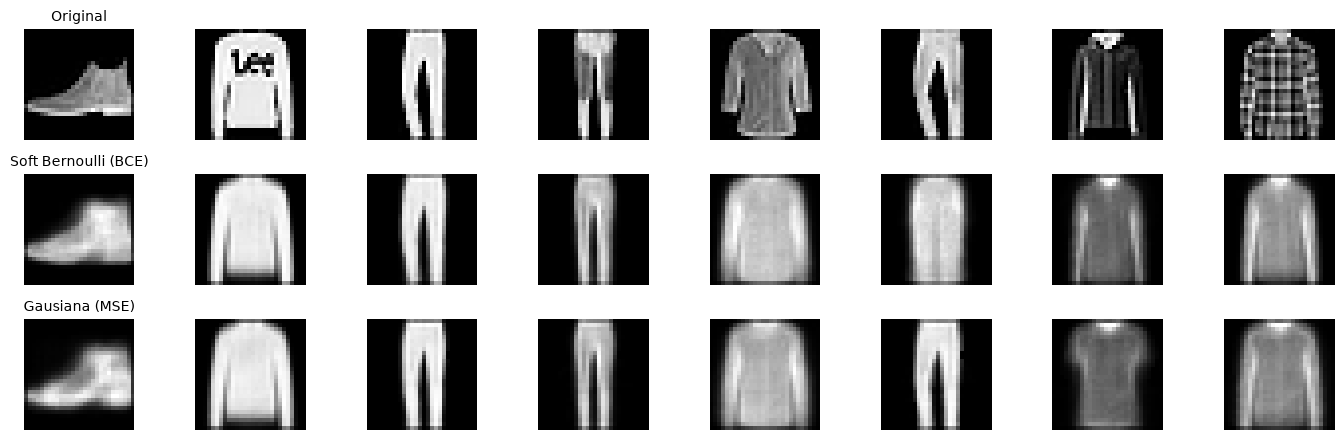

[INFO] Generando espacio latente - Soft Bernoulli...


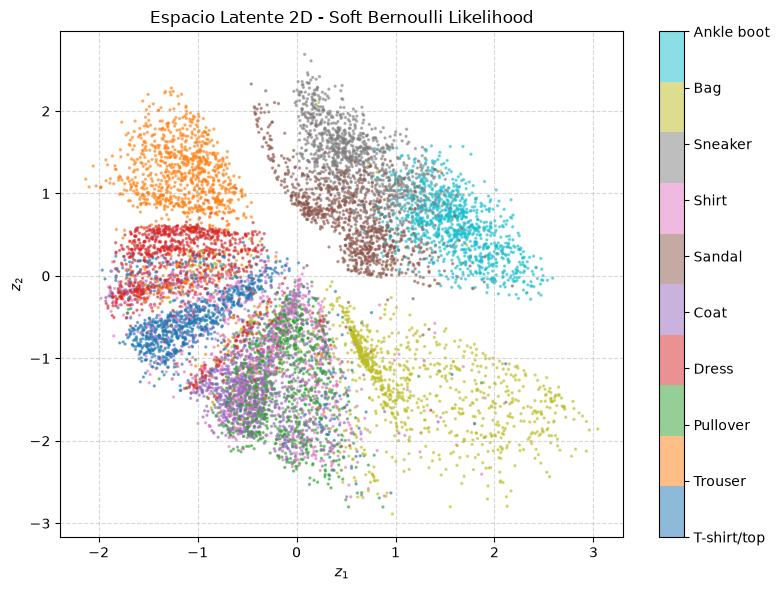

[INFO] Generando espacio latente - Gausiana...


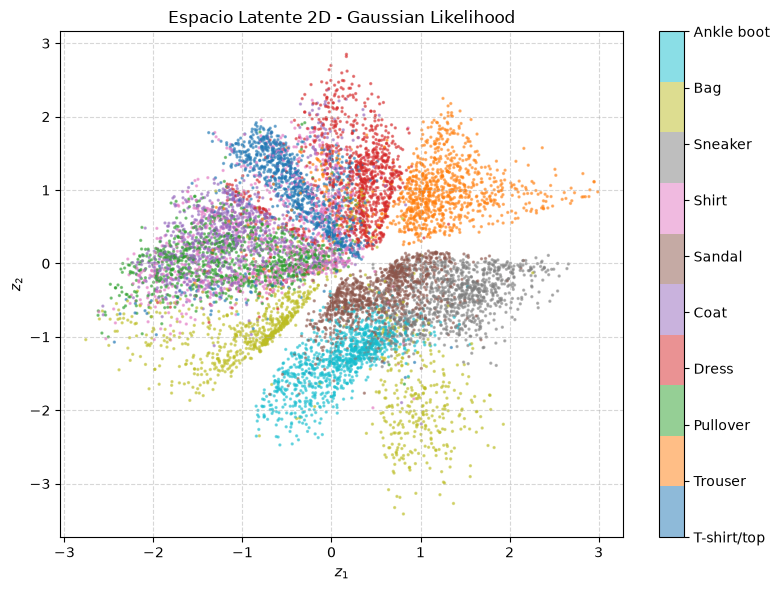

[INFO] Generando muestras sintéticas...


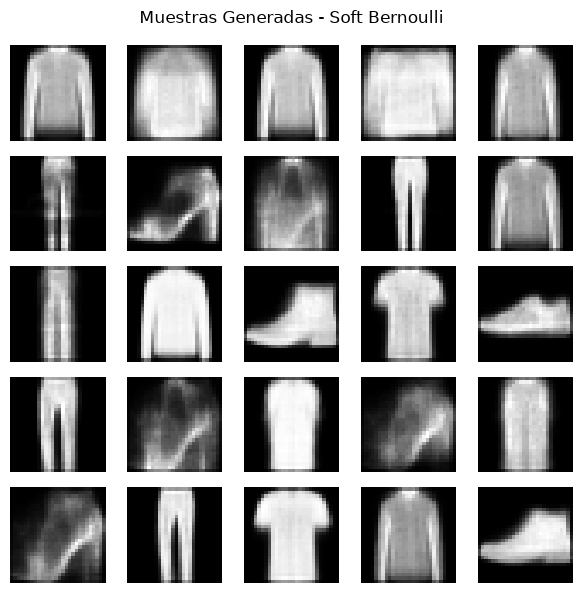

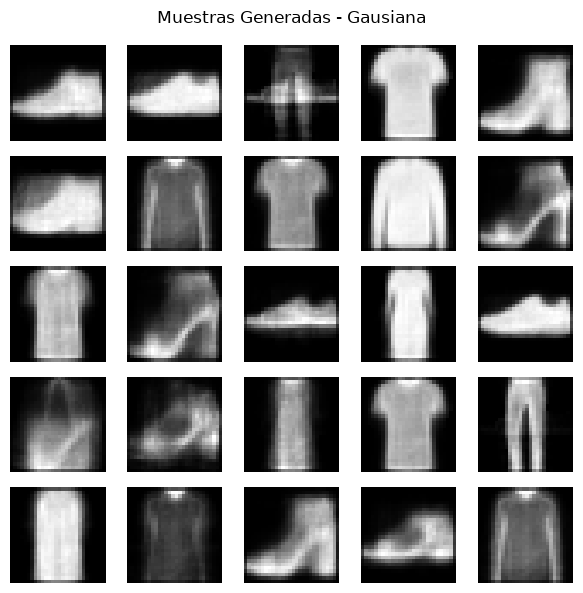

'\n===============================================================================\n7. DISCUSIÓN Y CONCLUSIONES TÉCNICAS\n===============================================================================\n1. DIFERENCIA DE LIKELIHOODS:\n   - BCE (Soft Bernoulli): Asume distribución de Bernoulli por píxel. Penaliza\n     fuertemente las divergencias en píxeles binarizados, logrando bordes nítidos.\n   - MSE (Gausiano): Asume ruido Gausiano con varianza constante. Penaliza la\n     distancia euclídea global, provocando un promediado que se observa como\n     efecto borroso ("blurry") en las prendas.\n\n2. ESTRUCTURA LATENTE:\n   - La pérdida KL comprime las distribuciones hacia N(0, I), garantizando que no\n     queden agujeros vacíos en el espacio y permitiendo la generación continua.\n===============================================================================\n'

In [1]:
"""
===============================================================================
 AUTOENCODER VARIACIONAL (VAE) EN FASHION-MNIST: FELIX ALEJANDRO GUGLIELMI PARRA
===============================================================================

"""

import os
import gc

# Prevenir el fallo crítico de OpenMP en Jupyter/Anaconda que apaga el kernel
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Limpieza inicial de memoria RAM/GPU
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =============================================================================
# CONFIGURACIÓN DE DISPOSITIVO Y SEMILLA
# =============================================================================
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Dispositivo seleccionado: {device}")

# =============================================================================
# 1. CARGA DE DATOS OPTIMIZADA (num_workers=0 previene congelamiento de kernel)
# =============================================================================
transform = transforms.Compose([
    transforms.ToTensor()
])

batch_size = 128

train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# num_workers=0 evita deadlocks del kernel en entornos Jupyter locales/Windows/macOS
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# =============================================================================
# 2. ARQUITECTURA DEL MODELO VAE
# =============================================================================
class VAE(nn.Module):
    """
    Encoder: x (784-dim) -> mu, logvar (z_dim)
    Decoder: z (z_dim) -> x_recon (784-dim)
    """
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=2, likelihood='bernoulli'):
        super(VAE, self).__init__()
        self.likelihood = likelihood
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder_body = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)
        
        # Decoder
        self.decoder_body = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder_body(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # Truco de reparametrización z = mu + std * eps
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_body(z)
        return torch.sigmoid(h)

    def forward(self, x):
        x_flat = x.view(-1, 784)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# =============================================================================
# 3. FUNCIÓN DE PÉRDIDA (-ELBO)
# =============================================================================
def vae_loss_function(x_recon, x, mu, logvar, likelihood='bernoulli'):
    x_flat = x.view(-1, 784)
    
    # Pérdida de reconstrucción
    if likelihood == 'bernoulli':
        recon_loss = F.binary_cross_entropy(x_recon, x_flat, reduction='sum')
    elif likelihood == 'gaussian':
        recon_loss = F.mse_loss(x_recon, x_flat, reduction='sum')
    else:
        raise ValueError("Likelihood no válido.")
        
    # Divergencia KL
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kl_loss, recon_loss, kl_loss

# =============================================================================
# 4. BUCLE DE ENTRENAMIENTO EFICIENTE
# =============================================================================
def train_vae(model, dataloader, optimizer, epochs=15, likelihood='bernoulli'):
    model.train()
    history = {'total_loss': [], 'recon_loss': [], 'kl_loss': []}
    
    for epoch in range(epochs):
        train_loss, train_recon, train_kl = 0.0, 0.0, 0.0
        for x, _ in dataloader:
            x = x.to(device)
            optimizer.zero_grad()
            
            x_recon, mu, logvar = model(x)
            loss, recon, kl = vae_loss_function(x_recon, x, mu, logvar, likelihood=likelihood)
            
            loss.backward()
            optimizer.step()
            
            # .item() extrae el escalar flotante sin mantener el grafo en memoria
            train_loss += loss.item()
            train_recon += recon.item()
            train_kl += kl.item()
            
        num_samples = len(dataloader.dataset)
        avg_loss = train_loss / num_samples
        avg_recon = train_recon / num_samples
        avg_kl = train_kl / num_samples
        
        history['total_loss'].append(avg_loss)
        history['recon_loss'].append(avg_recon)
        history['kl_loss'].append(avg_kl)
        
        print(f"Época {epoch+1:02d}/{epochs:02d} | Pérdida Total: {avg_loss:.2f} | Recon: {avg_recon:.2f} | KL: {avg_kl:.2f}")
        
    return history

# =============================================================================
# 5. ENTRENAMIENTO DE MODELOS
# =============================================================================
epochs = 15
latent_dim = 2

print("\n=== [1/2] Entrenando VAE Soft Bernoulli ===")
vae_bernoulli = VAE(latent_dim=latent_dim, likelihood='bernoulli').to(device)
optimizer_b = optim.Adam(vae_bernoulli.parameters(), lr=1e-3)
hist_bernoulli = train_vae(vae_bernoulli, train_loader, optimizer_b, epochs=epochs, likelihood='bernoulli')

print("\n=== [2/2] Entrenando VAE Gausiano ===")
vae_gaussian = VAE(latent_dim=latent_dim, likelihood='gaussian').to(device)
optimizer_g = optim.Adam(vae_gaussian.parameters(), lr=1e-3)
hist_gaussian = train_vae(vae_gaussian, train_loader, optimizer_g, epochs=epochs, likelihood='gaussian')

# =============================================================================
# 6. VISUALIZACIONES (Liberando memoria de gráficos explícitamente)
# =============================================================================

def plot_reconstructions(model_b, model_g, dataloader, num_images=8):
    model_b.eval()
    model_g.eval()
    
    with torch.no_grad():
        x_test, _ = next(iter(dataloader))
        x_test = x_test[:num_images].to(device)
        recon_b, _, _ = model_b(x_test)
        recon_g, _, _ = model_g(x_test)
        
    x_test = x_test.cpu().numpy()
    recon_b = recon_b.view(-1, 28, 28).cpu().numpy()
    recon_g = recon_g.view(-1, 28, 28).cpu().numpy()
    
    fig, axes = plt.subplots(3, num_images, figsize=(14, 4.5))
    for i in range(num_images):
        axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("Original", fontsize=10)
            
        axes[1, i].imshow(recon_b[i], cmap='gray')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title("Soft Bernoulli (BCE)", fontsize=10)
            
        axes[2, i].imshow(recon_g[i], cmap='gray')
        axes[2, i].axis('off')
        if i == 0: axes[2, i].set_title("Gausiana (MSE)", fontsize=10)
            
    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_latent_space(model, dataloader, title="Espacio Latente 2D"):
    model.eval()
    all_mus = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            mu, _ = model.encode(x.view(-1, 784))
            all_mus.append(mu.cpu().numpy())
            all_labels.append(y.numpy())
            
    mus = np.concatenate(all_mus, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    
    fig = plt.figure(figsize=(8, 6))
    scatter = plt.scatter(mus[:, 0], mus[:, 1], c=labels, cmap='tab10', alpha=0.5, s=2)
    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.ax.set_yticklabels(classes)
    plt.xlabel(r"$z_1$")
    plt.ylabel(r"$z_2$")
    plt.title(title, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_generated_samples(model, title="Muestras Generadas de p(z)", grid_size=5):
    model.eval()
    with torch.no_grad():
        z_samples = torch.randn(grid_size * grid_size, model.latent_dim).to(device)
        generated = model.decode(z_samples).view(-1, 28, 28).cpu().numpy()
        
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
    for i in range(grid_size):
        for j in range(grid_size):
            idx = i * grid_size + j
            axes[i, j].imshow(generated[idx], cmap='gray')
            axes[i, j].axis('off')
            
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Ejecución de visualizaciones de forma limpia
print("\n[INFO] Generando comparativas de reconstrucción...")
plot_reconstructions(vae_bernoulli, vae_gaussian, test_loader)

print("[INFO] Generando espacio latente - Soft Bernoulli...")
plot_latent_space(vae_bernoulli, test_loader, title="Espacio Latente 2D - Soft Bernoulli Likelihood")

print("[INFO] Generando espacio latente - Gausiana...")
plot_latent_space(vae_gaussian, test_loader, title="Espacio Latente 2D - Gaussian Likelihood")

print("[INFO] Generando muestras sintéticas...")
plot_generated_samples(vae_bernoulli, title="Muestras Generadas - Soft Bernoulli")
plot_generated_samples(vae_gaussian, title="Muestras Generadas - Gausiana")

# Limpieza final de garbage collector
gc.collect()

"""
===============================================================================
7. DISCUSIÓN Y CONCLUSIONES TÉCNICAS
===============================================================================
1. DIFERENCIA DE LIKELIHOODS:
   - BCE (Soft Bernoulli): Asume distribución de Bernoulli por píxel. Penaliza
     fuertemente las divergencias en píxeles binarizados, logrando bordes nítidos.
   - MSE (Gausiano): Asume ruido Gausiano con varianza constante. Penaliza la
     distancia euclídea global, provocando un promediado que se observa como
     efecto borroso ("blurry") en las prendas.

2. ESTRUCTURA LATENTE:
   - La pérdida KL comprime las distribuciones hacia N(0, I), garantizando que no
     queden agujeros vacíos en el espacio y permitiendo la generación continua.
===============================================================================
"""

## Exercise 2: Advanced VAE - GMM-VAE or VQ-VAE

Based on your results from Exercise 1, choose the best encoder likelihood and complete the following tasks:
1. Implement and train either a GMM-VAE or a VQ-VAE using the best likelihood from Exercise 1.
2. Visualize and analyze the latent space of your chosen model.
3. Compare the results with the standard VAE.

## Exercise 3: Comparison with Conditional Models

In this section, you will:
- Compare the latent spaces of your advanced VAE (GMM-VAE or VQ-VAE) with a conditional VAE.
- Discuss similarities and differences in the latent representations.




### Conditional Generative Models
There are three types of variables in a deep conditional generative model (CGM): input variables $\mathbf{y}$, output variables $\mathbf{x}$, and latent variables $\mathbf{z}$. The conditional generative process of the model is as follows: for a given observation $\mathbf{y}$, $\mathbf{z}$ is drawn from the prior distribution $p_\theta(\mathbf{z}|\mathbf{y})$, and the output $\mathbf{x}$ is generated from the distribution $p_\theta(\mathbf{x}|\mathbf{y}, \mathbf{z})$. The prior of the latent variables $\mathbf{z}$ is modulated by the input $\mathbf{y}$ in our formulation; however, the constraint can be easily relaxed to make the latent variables statistically independent of input variables, i.e., $p_\theta(\mathbf{z}|\mathbf{y}) = p_\theta(\mathbf{z})$.


### Conditional Generative Model

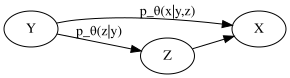

### Recognition Model

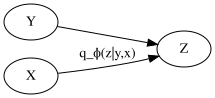

In [ ]:
from graphviz import Digraph
from IPython.display import display, Markdown


def is_google_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False


# Run this if we are in google colab
if is_google_colab():
    # First diagram: Generative model
    g1 = Digraph('Generative_Model')
    g1.attr(rankdir='LR')
    g1.node('Y')
    g1.node('X')
    g1.node('Z')
    g1.edge('Y', 'Z', label='p_θ(z|y)')
    g1.edge('Z', 'X')
    g1.edge('Y', 'X', label='p_θ(x|y,z)')

    # Second diagram: Recognition (inference) model
    g2 = Digraph('Recognition_Model')
    g2.attr(rankdir='LR')
    g2.node('Y')
    g2.node('X')
    g2.node('Z')
    g2.edge('Y', 'Z')
    g2.edge('X', 'Z', label='q_ϕ(z|y,x)')

    # Display with titles
    display(Markdown("### Conditional Generative Model"))
    display(g1)
    display(Markdown("### Recognition Model"))
    display(g2)


Deep CGMs are trained to maximize the conditional log-likelihood. Often the objective function is intractable, and we apply the stochastic variational inference framework to train the model. The variational lower bound of the model is written as follows:

\begin{equation}
\log p_\theta(\mathbf{x}|\mathbf{y}) \geq -\mathrm{KL}\left(q_\phi(\mathbf{z}|\mathbf{x}, \mathbf{y}) \| p_\theta(\mathbf{z}|\mathbf{y})\right) + \mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x}, \mathbf{y})}\left[\log p_\theta(\mathbf{x}|\mathbf{y}, \mathbf{z})\right]
\end{equation}

and the empirical lower bound is written as:

\begin{equation}
\widetilde{\mathcal{L}}_{\text{CVAE}}(\mathbf{x}, \mathbf{y}; \theta, \phi) = -\mathrm{KL}\left(q_\phi(\mathbf{z}|\mathbf{x}, \mathbf{y}) \| p_\theta(\mathbf{z}|\mathbf{y})\right) + \frac{1}{L} \sum_{l=1}^{L} \log p_\theta(\mathbf{x}|\mathbf{y}, \mathbf{z}^{(l)}),
\end{equation}

where $\mathbf{z}^{(l)} = g_\phi(\mathbf{x}, \mathbf{y}; \epsilon^{(l)})$, $\epsilon^{(l)} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and $L$ is the number of samples. We call this model *conditional variational auto-encoder* (CVAE). The CVAE is composed of multiple MLPs, such as recognition network $q_\phi(\mathbf{z}|\mathbf{x}, \mathbf{y})$, (conditional) prior network $p_\theta(\mathbf{z}|\mathbf{y})$, and generation network $p_\theta(\mathbf{x}|\mathbf{y}, \mathbf{z})$.


### Implementing a Conditional VAE

#### **1. Implement a CVAE with Independent Prior**

- Use a **standard Gaussian prior**: $p(\mathbf{z}) = \mathcal{N}(0, I)$
- In this setting:
  - $\mathbf{y}$: class label (0–9)
  - $\mathbf{x}$: FMNIST image
- Feed the label $\mathbf{y}$ to the **decoder** $p_\theta(\mathbf{x} \mid \mathbf{y}, \mathbf{z})$, using either:
  - One-hot encoding
  - A learnable [embedding layer](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html)



#### **2. Modify the Prior to be Label-Dependent**

- Replace the independent prior with a **label-conditional prior**:

$$
p_\theta(\mathbf{z} \mid \mathbf{y})
$$

- Implement this using a small MLP that takes the class label as input (one-hot or embedding layer) and outputs $\mu(\mathbf{y})$, $\log\sigma^2(\mathbf{y})$
- Update the KL divergence accordingly:

$$
\mathrm{KL}\left(q_\phi(\mathbf{z} \mid \mathbf{x}, \mathbf{y}) \,\|\, p_\theta(\mathbf{z} \mid \mathbf{y})\right)
$$

In both cases:
- Plot the evolution of:
  - Total loss
  - KL divergence
  - Reconstruction loss
- After training:
  - Generate samples for each class label $\mathbf{y}$
  - Use the recognition network $q_\phi(\mathbf{z} \mid \mathbf{x}, \mathbf{y})$ to encode real test images
  - Visualize the resulting latent space using **t-SNE**, colored by class



## **Part 2: Missing Data Imputation with VAEs**

In this exercise, you'll work with the [Spambase dataset](https://archive.ics.uci.edu/dataset/94/spambase) from the UCI Machine Learning Repository. The goal is to use **Variational Autoencoders (VAEs)** to impute artificially introduced missing values in tabular data.

---

### **Step-by-Step Instructions**

1. **Download and Prepare the Dataset**
   - Load the Spambase dataset.
   - Normalize all features (ignore the `spam` label for now).
   - Split the dataset into **train** and **test** sets.

2. **Train a VAE**
   - Train a standard VAE using only the **clean (complete)** training set (i.e. no missing values).

3. **Simulate Missing Data in the Test Set**
   - Generate a **binary mask** for the test set where each entry has an 80% chance of being retained (True) and a 20% chance of being masked (False).
   - Replace all entries marked as missing (mask = False) with **zero**.

4. **Impute Missing Values**
   - Pass the **masked test set** through the VAE encoder.
   - Sample from the latent space and reconstruct the input using the decoder.
   - Use the decoder's output as the **imputed version** of the masked data.

5. **Evaluate Imputation Quality**
   - Compute the **Mean Squared Error (MSE)** and **R² score** over the **missing entries only** by comparing the imputed values against the original (unmasked) test set.

6. **Train a VAE with Random Masks (Imputation-Aware Training)**
   - Modify the training process:
     - At each iteration, apply a **random mask** to the training data (e.g. 20% of values masked).
     - Set the missing values to **0**.
     - Feed the masked data to the encoder.
     - When computing the loss (ELBO), evaluate **reconstruction over all entries (both observed and artificially masked)**.
     - KL divergence is computed as usual.

7. **Re-evaluate on the Test Set**
   - Using the **retrained VAE**, repeat Steps 3–5:
     - Apply a 20% missing mask to the test set.
     - Perform imputation using the retrained model.
     - Compute and report **MSE** and **R²** over the missing values.
